<a href="https://colab.research.google.com/github/adelinda02/ade-linda/blob/main/dataset_haberman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Import the pandas library as pd
import pandas as pd

# Read 'haberman.csv' into a DataFrame named ri
ri = pd.read_csv('/content/haberman.csv')

In [76]:
print(ri.shape)
print (ri.columns)
ri.head()

(305, 4)
Index(['30', '64', '1', '1.1'], dtype='object')


,30,64,1,1.1
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1
3,31,65,4,1
4,33,58,10,1


In [77]:
ri.columns = ["Age","Operation_Year","positive_lymph_nodes","Survival status"]
print (ri.columns)
ri.head()

Index(['Age', 'Operation_Year', 'positive_lymph_nodes', 'Survival status'], dtype='object')


,Age,Operation_Year,positive_lymph_nodes,Survival status
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1
3,31,65,4,1
4,33,58,10,1


In [78]:
ri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   305 non-null    int64
 1   Operation_Year        305 non-null    int64
 2   positive_lymph_nodes  305 non-null    int64
 3   Survival status       305 non-null    int64
dtypes: int64(4)
memory usage: 9.7 KB


In [79]:
ri["Survival status"].value_counts()

,count
Survival status,
1,224
2,81


In [80]:
ri.describe()

,Age,Operation_Year,positive_lymph_nodes,Survival status
count,305.000000,305.000000,305.000000,305.000000
mean,52.531148,62.849180,4.036066,1.265574
std,10.744024,3.254078,7.199370,0.442364
min,30.000000,58.000000,0.000000,1.000000
25%,44.000000,60.000000,0.000000,1.000000
50%,52.000000,63.000000,1.000000,1.000000
75%,61.000000,66.000000,4.000000,2.000000
max,83.000000,69.000000,52.000000,2.000000


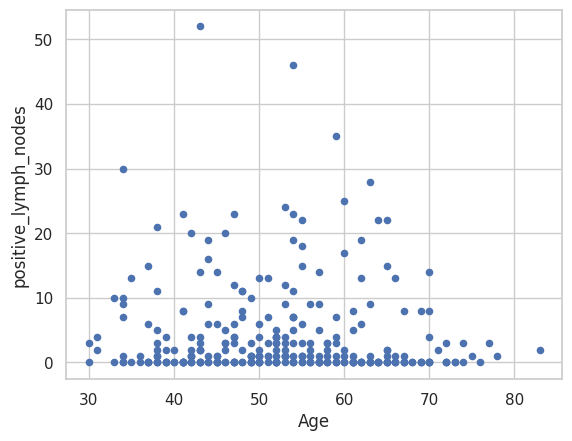

In [81]:
ri.plot(kind='scatter', x='Age', y='positive_lymph_nodes') ;
plt.show()

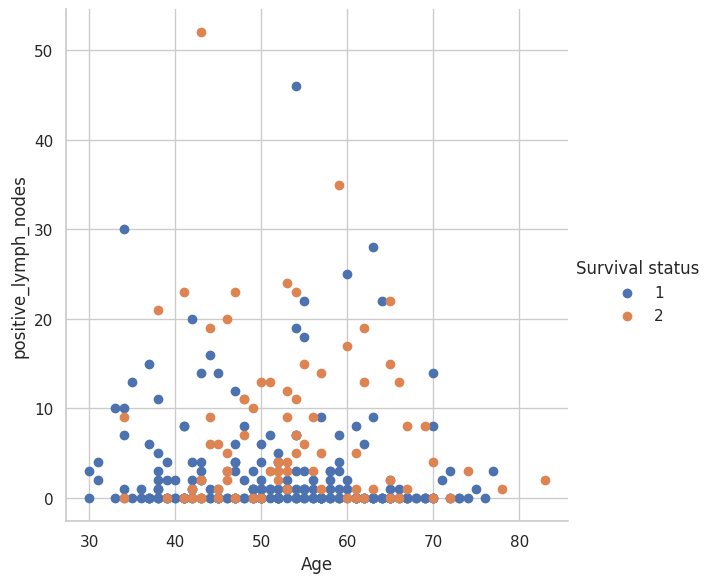

In [82]:
sns.set_style("whitegrid");
sns.FacetGrid(ri, hue="Survival status", height=6) \
   .map(plt.scatter, "Age", "positive_lymph_nodes") \
   .add_legend();
plt.show();

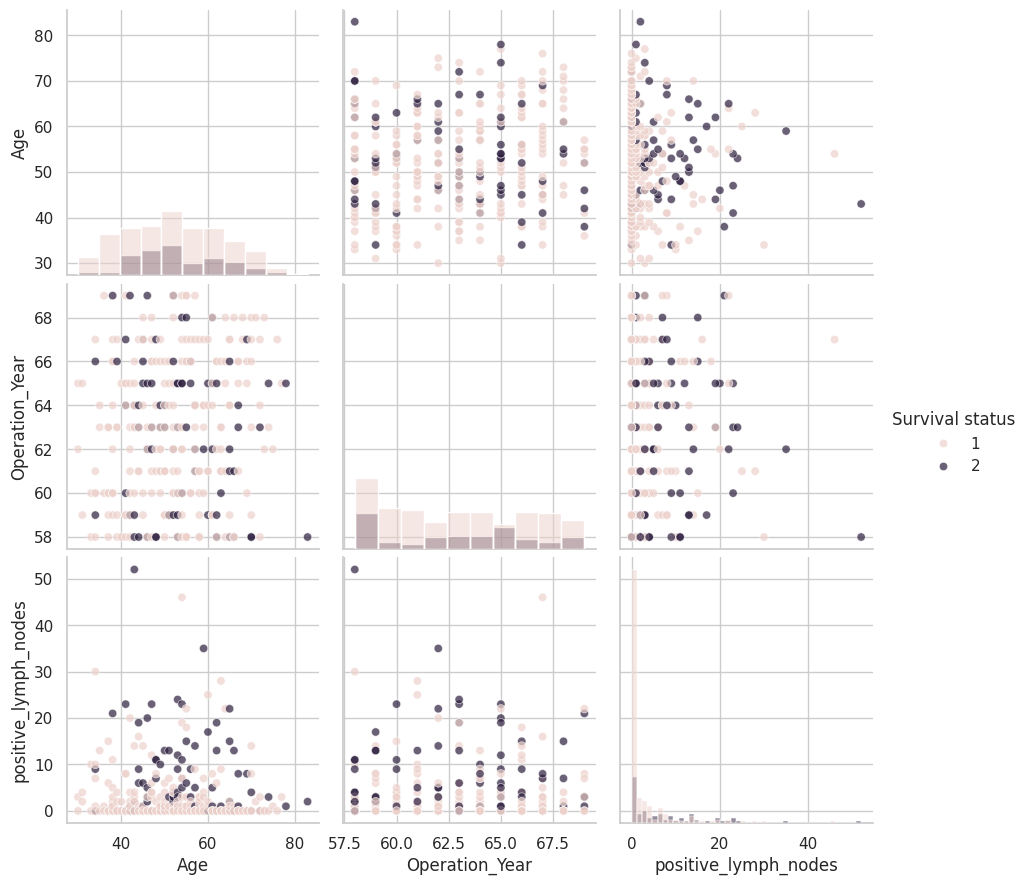

In [83]:
sns.pairplot(
    data=ri,
    hue="Survival status",
    vars=['Age', 'Operation_Year', 'positive_lymph_nodes'],
    height=3,
    diag_kind='hist',
    plot_kws={'alpha': 0.7}
)

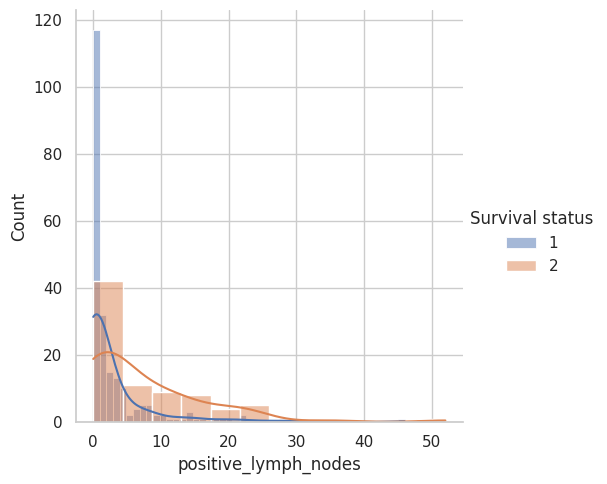

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.FacetGrid(ri, hue="Survival status", height=5) \
   .map(sns.histplot, "positive_lymph_nodes", kde=True) \
   .add_legend()

plt.show()

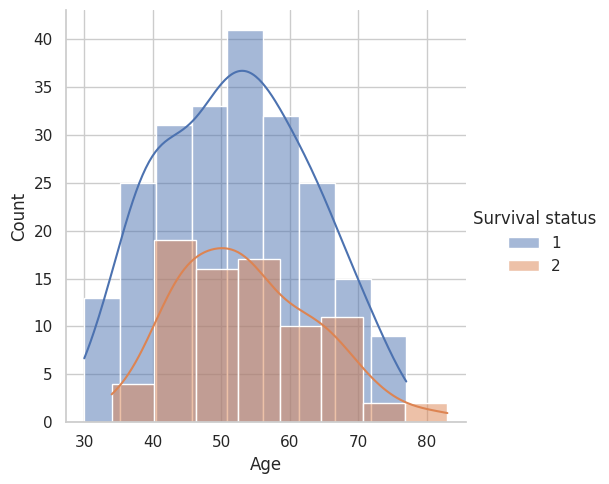

In [85]:
sns.FacetGrid(ri, hue="Survival status", height=5) \
   .map(sns.histplot, "Age", kde=True) \
   .add_legend();
plt.show();

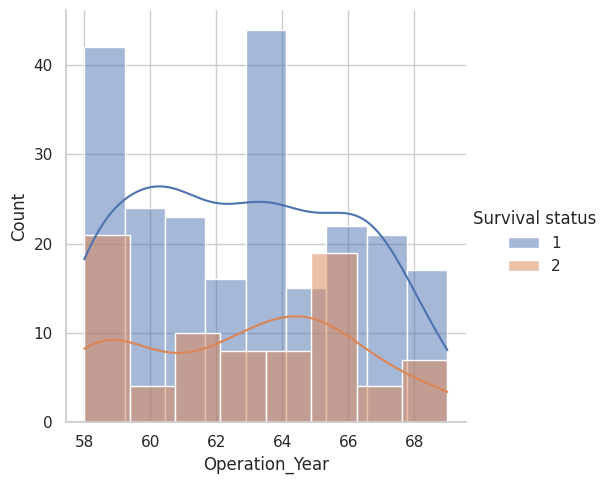

In [86]:
sns.FacetGrid(ri, hue="Survival status", height=5) \
   .map(sns.histplot, "Operation_Year", kde=True) \
   .add_legend();
plt.show();

[0.83482143 0.08035714 0.02232143 0.02678571 0.01785714 0.00446429
 0.00892857 0.         0.         0.00446429]
[ 0.   4.6  9.2 13.8 18.4 23.  27.6 32.2 36.8 41.4 46. ]


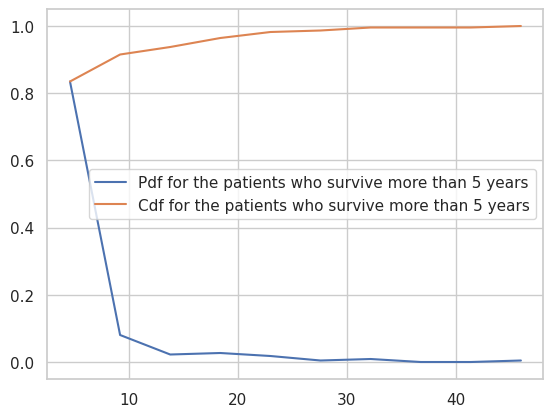

In [87]:
alive=ri.loc[ri["Survival status"]==1]
dead=ri.loc[ri["Survival status"]==2]
counts, bin_edges = np.histogram(alive['positive_lymph_nodes'], bins=10,
                                 density = True)
pdf = counts/(sum(counts))
print(pdf);
print(bin_edges)
cdf = np.cumsum(pdf)
plt.plot(bin_edges[1:],pdf)
plt.plot(bin_edges[1:], cdf)
plt.legend(['Pdf for the patients who survive more than 5 years',
            'Cdf for the patients who survive more than 5 years'])
plt.show()

[0.56790123 0.14814815 0.13580247 0.04938272 0.07407407 0.
 0.01234568 0.         0.         0.01234568]
[ 0.   5.2 10.4 15.6 20.8 26.  31.2 36.4 41.6 46.8 52. ]


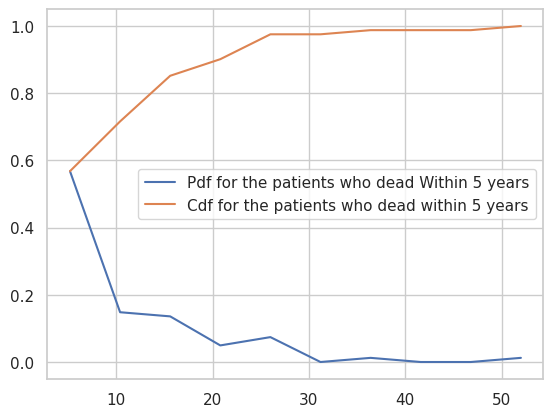

In [88]:
counts, bin_edges = np.histogram(dead['positive_lymph_nodes'], bins=10, density=True)

pdf = counts/(sum(counts))
print(pdf);
print(bin_edges)
cdf = np.cumsum(pdf)
plt.plot(bin_edges[1:],pdf)
plt.plot(bin_edges[1:], cdf)
plt.legend(['Pdf for the patients who dead Within 5 years',
            'Cdf for the patients who dead within 5 years'])
plt.show()

In [89]:
print("Summary Statistics of Patients who are alive for more than 5 years:")
alive.describe()

Summary Statistics of Patients who are alive for more than 5 years:


,Age,Operation_Year,positive_lymph_nodes,Survival status
count,224.000000,224.000000,224.000000,224.0
mean,52.116071,62.857143,2.799107,1.0
std,10.937446,3.229231,5.882237,0.0
min,30.000000,58.000000,0.000000,1.0
25%,43.000000,60.000000,0.000000,1.0
50%,52.000000,63.000000,0.000000,1.0
75%,60.000000,66.000000,3.000000,1.0
max,77.000000,69.000000,46.000000,1.0


In [90]:
print("Summary Statistics of Patients who are dead within 5 years:")
dead.describe()

Summary Statistics of Patients who are dead within 5 years:


,Age,Operation_Year,positive_lymph_nodes,Survival status
count,81.000000,81.000000,81.000000,81.0
mean,53.679012,62.827160,7.456790,2.0
std,10.167137,3.342118,9.185654,0.0
min,34.000000,58.000000,0.000000,2.0
25%,46.000000,59.000000,1.000000,2.0
50%,53.000000,63.000000,4.000000,2.0
75%,61.000000,65.000000,11.000000,2.0
max,83.000000,69.000000,52.000000,2.0


In [91]:
#Median, Quantiles, Percentiles, IQR.
print("\nMedians:")
print(np.median(alive["positive_lymph_nodes"]))
#Median with an outlier
print(np.median(np.append(alive["positive_lymph_nodes"],50)));
print(np.median(dead["positive_lymph_nodes"]))

print("\nQuantiles:")
print(np.percentile(alive["positive_lymph_nodes"],np.arange(0, 100, 25)))
print(np.percentile(dead["positive_lymph_nodes"],np.arange(0, 100, 25)))

print("\n90th Percentiles:")
print(np.percentile(alive["positive_lymph_nodes"],90))
print(np.percentile(dead["positive_lymph_nodes"],90))

from statsmodels import robust
print ("\nMedian Absolute Deviation")
print(robust.mad(alive["positive_lymph_nodes"]))
print(robust.mad(dead["positive_lymph_nodes"]))


Medians:
0.0
0.0
4.0

Quantiles:
[0. 0. 0. 3.]
[ 0.  1.  4. 11.]

90th Percentiles:
8.0
20.0

Median Absolute Deviation
0.0
5.930408874022408


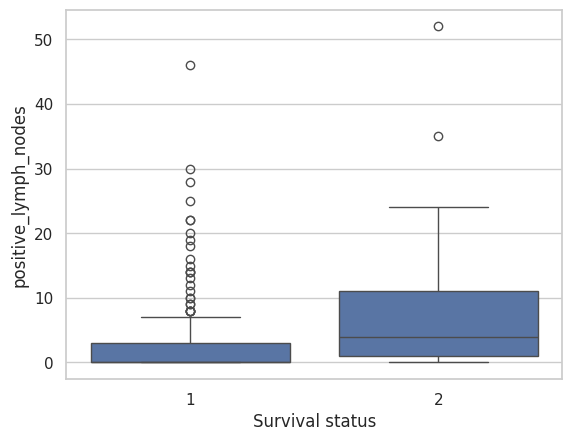

In [92]:
"""
Box plot takes a less space and visually represents the five number summary of the data points in a box.
The outliers are displayed as points outside the box.
1. Q1 - 1.5*IQR
2. Q1 (25th percentile)
3. Q2 (50th percentile or median)
4. Q3 (75th percentile)
5. Q3 + 1.5*IQR
Inter Quartile Range = Q3 -Q1
"""

sns.boxplot(x='Survival status',y='positive_lymph_nodes', data=ri)
plt.show()

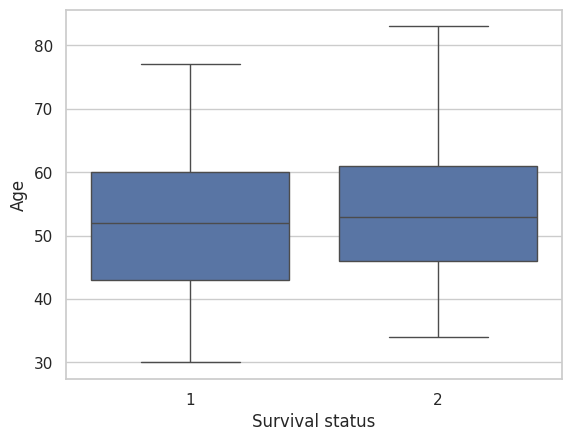

In [93]:
sns.boxplot(x='Survival status',y='Age', data=ri)
plt.show()

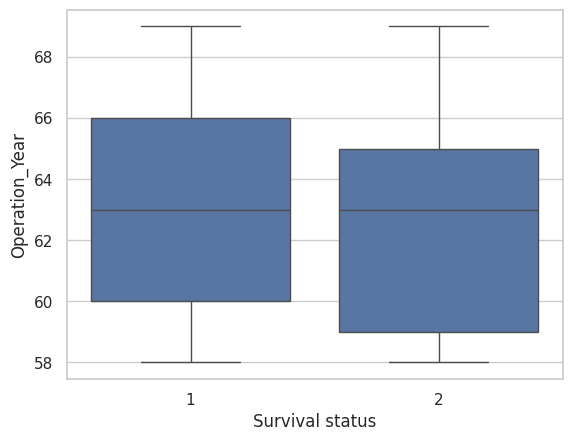

In [94]:
sns.boxplot(x='Survival status',y='Operation_Year', data=ri)
plt.show()

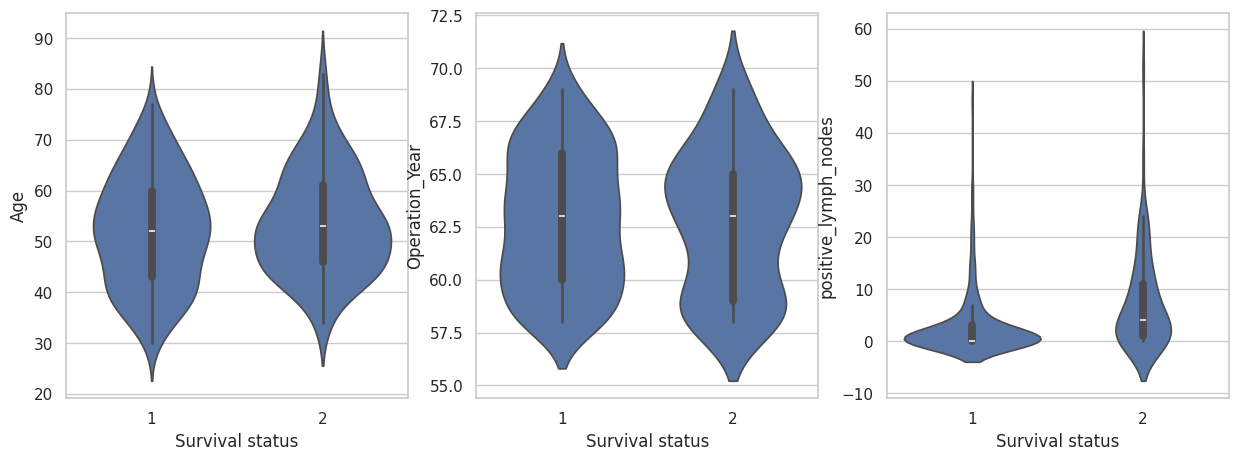

In [95]:
#Violin plot is the combination of box plot and probability density function.
#Denser regions of the data are fatter, and sparser ones thinner in a violin plot.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, feature in enumerate(list(ri.columns)[:-1]):
    sns.violinplot( x='Survival status', y=feature, data=ri, ax=axes[idx])
plt.show()

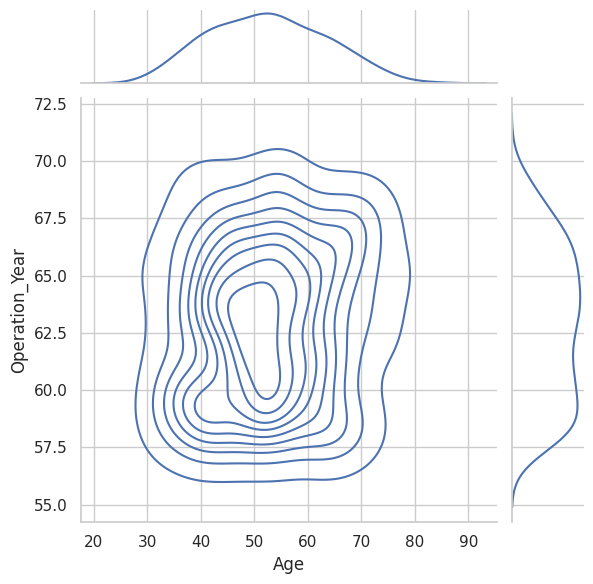

In [96]:
sns.jointplot(x="Age", y="Operation_Year", data=ri, kind="kde");
plt.show()